In [36]:
from dotenv import load_dotenv 
import os 
from typing import TypedDict, List
from langchain_core.messages import HumanMessage , AIMessage , BaseMessage
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
#langGraph is built on top of langChain
load_dotenv(override=True)

True

In [37]:
# HumanMessage in LangChain represents a message sent by the user (human)
# It is part of LangChain's structured chat message system

# LangChain uses different message types to represent conversation roles:
# - SystemMessage  -> system instructions (rules, behavior)
# - HumanMessage   -> user input
# - AIMessage      -> model response
# - ToolMessage    -> tool output

#eg :  SystemMessage(content="You are a helpful assistant"),  # system role
# In most cases, you do NOT need to create HumanMessage manually
# LangChain automatically converts inputs to HumanMessage when using:
# - ChatPromptTemplate
# - agent_executor.invoke()
# - Runnable pipelines

# You usually create HumanMessage manually only for:
# - low-level message handling
# - custom agents or routers
# - replaying or modifying chat history

In [42]:
class AgentState(TypedDict):
    messages : List[BaseMessage]

llm = ChatOpenAI(model='openai/gpt-4o' , api_key=os.getenv('LLM_API_KEY') , base_url=os.getenv('BASE_URL'))

In [47]:
# If you pass a LIST of HumanMessage objects to an LLM,
# the model treats them as a conversation history
def setup(state : AgentState) -> AgentState: 
    state['messages'] = state.get('messages',[])
    return state 

def process(state: AgentState) -> AgentState: 
    response = llm.invoke(state['messages'])
    print(f'Message : {state["messages"][-1].content}\n')
    print(f'\nAI: {response.content}')

    state['messages'].append(
        AIMessage(content=response.content)
    )    # ✅ append AI response to conversation history

    return state 



graph = StateGraph(AgentState)

graph.add_node("setup", setup)
graph.add_node("process", process)

graph.add_edge(START, "setup")
graph.add_edge("setup", "process")
graph.add_edge("process", END)

agent = graph.compile()




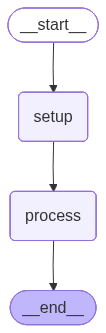

In [48]:
from IPython.display import Image
Image(agent.get_graph().draw_mermaid_png())

In [49]:
user_input = input("Enter the message: ")

agent.invoke({
    "messages": [HumanMessage(content=user_input)]
})


Message : hi


AI: Hello! How can I assist you today?


{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}

In [50]:
user_input = input("Enter the message: ")
while user_input != 'exit':
    agent.invoke({'messages': [HumanMessage(content=user_input)]})
    user_input = input("Enter the message: ")

Message : yo whatsup 


AI: Hey! Not much, just here to help. What’s up with you?
Message : generate a 2 sum code 


AI: Certainly! The "2-sum" problem involves finding two numbers in an array that add up to a specific target sum. Below is a Python function that implements a solution to the 2-sum problem using a hash map for efficient lookup:

```python
def two_sum(nums, target):
    num_map = {}  # To store the number and its index
    for i, num in enumerate(nums):
        complement = target - num
        if complement in num_map:
            return [num_map[complement], i]
        num_map[num] = i
    return None  # If there is no solution

# Example usage:
nums = [2, 7, 11, 15]
target = 9
result = two_sum(nums, target)
print("Indices of the numbers that add up to the target are:", result)
```

### Explanation:
- **Hash Map (`num_map`)**: The dictionary keeps track of numbers and their indices.
- **Loop Through List (`nums`)**: For each number, calculate its complementary number ne